In [ ]:
# ----------------------------------------
#import all the required packages:
# ----------------------------------------

import pandas as pd
import numpy as np
import sklearn
from sklearn import (cluster,
                     datasets,
                     decomposition,
                     discriminant_analysis,
                     dummy,
                     ensemble,
                     feature_selection as ftr_sel,
                     linear_model,
                     metrics,
                     model_selection as skms,
                     multiclass as skmulti,
                     naive_bayes,
                     neighbors,
                     pipeline,
                     preprocessing as skpre,
                     svm,
                     tree)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import collections as co
import itertools as it
%matplotlib inline


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# --------------------------------------------
# Mounting google colab
# --------------------------------------------

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

print(os.listdir('/content/drive/MyDrive/Colab Notebooks/Final Machine Learning Project'))

['patient_adherence_dataset.csv', 'BUA 611_3311_Term Project SP26.pdf', 'Final Presentation Canva - NEW LINK.webloc', 'Final Presentation Canva - OLD.url', 'Final (1).ipynb', 'BUA611_Presentation.pptx', 'BUA611_FinalProject_Report.docx', 'BUA611_Presentation_Script.docx', 'Final_One_Hot_Encoding.ipynb', '10_Manual_Feature_Engineering_code_updated (2).ipynb', 'Final.ipynb']


In [ ]:
# --------------------------------------------
# Setting a working directory
# --------------------------------------------

FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/Final Machine Learning Project/patient_adherence_dataset.csv'

df = pd.read_csv(FILE_PATH)


In [ ]:
# --------------------------------------------
# Loading the dataset
# --------------------------------------------

print('Shape:', df.shape)
df.head()

Shape: (5000, 14)


,Age,Gender,Medication_Type,Dosage_mg,Previous_Adherence,Education_Level,Income,Social_Support_Level,Condition_Severity,Comorbidities_Count,Healthcare_Access,Mental_Health_Status,Insurance_Coverage,Adherence
0,57,Male,TypeA,136,1,High School,634934,Medium,Severe,3,Poor,Good,1,1
1,47,Male,TypeA,134,1,High School,297954,High,Moderate,3,Good,Good,1,0
2,59,Male,TypeC,89,1,High School,789337,High,Moderate,1,Good,Good,1,1
3,72,Male,TypeB,240,0,Postgraduate,267352,Low,Mild,2,Poor,Moderate,1,0
4,46,Male,TypeA,241,1,Postgraduate,718447,Medium,Mild,1,Poor,Good,1,0


In [ ]:
# --------------------------------------------
# Data Inspection
# --------------------------------------------

print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Duplicates ---')
print('Duplicate rows:', df.duplicated().sum())

--- Data Types ---
Age                      int64
Gender                  object
Medication_Type         object
Dosage_mg                int64
Previous_Adherence       int64
Education_Level         object
Income                   int64
Social_Support_Level    object
Condition_Severity      object
Comorbidities_Count      int64
Healthcare_Access       object
Mental_Health_Status    object
Insurance_Coverage       int64
Adherence                int64
dtype: object

--- Missing Values ---
Age                     0
Gender                  0
Medication_Type         0
Dosage_mg               0
Previous_Adherence      0
Education_Level         0
Income                  0
Social_Support_Level    0
Condition_Severity      0
Comorbidities_Count     0
Healthcare_Access       0
Mental_Health_Status    0
Insurance_Coverage      0
Adherence               0
dtype: int64

--- Duplicates ---
Duplicate rows: 0


In [ ]:
# --------------------------------------------
# Descriptive Statistics and Key observations
# --------------------------------------------

df.describe(include='all')

,Age,Gender,Medication_Type,Dosage_mg,Previous_Adherence,Education_Level,Income,Social_Support_Level,Condition_Severity,Comorbidities_Count,Healthcare_Access,Mental_Health_Status,Insurance_Coverage,Adherence
count,5000.000000,5000,5000,5000.000000,5000.000000,5000,5.000000e+03,5000,5000,5000.00000,5000,5000,5000.000000,5000.000000
unique,NaN,3,3,NaN,NaN,3,NaN,3,3,NaN,3,3,NaN,NaN
top,NaN,Female,TypeA,NaN,NaN,High School,NaN,Medium,Mild,NaN,Average,Good,NaN,NaN
freq,NaN,2492,2019,NaN,NaN,2062,NaN,1986,2535,NaN,2033,2513,NaN,NaN
mean,49.665600,NaN,NaN,200.893000,0.702400,NaN,5.009179e+05,NaN,NaN,2.01480,NaN,NaN,0.800800,0.457200
std,14.641689,NaN,NaN,50.556819,0.457248,NaN,1.968861e+05,NaN,NaN,1.40149,NaN,NaN,0.399439,0.498215
min,18.000000,NaN,NaN,50.000000,0.000000,NaN,1.000000e+05,NaN,NaN,0.00000,NaN,NaN,0.000000,0.000000
25%,40.000000,NaN,NaN,166.000000,0.000000,NaN,3.607158e+05,NaN,NaN,1.00000,NaN,NaN,1.000000,0.000000
50%,50.000000,NaN,NaN,201.000000,1.000000,NaN,5.010565e+05,NaN,NaN,2.00000,NaN,NaN,1.000000,0.000000
75%,59.000000,NaN,NaN,235.000000,1.000000,NaN,6.381558e+05,NaN,NaN,3.00000,NaN,NaN,1.000000,1.000000


Key observations:

1.   Dataset has 5,000 complete observations with no missing values.
2.  Average patient age is approximately 50 years and the dosage ranges widely from 50mg to 423mg.
3. Average income is approximately $201K with high variability.
4. Target variable Adherence: 45.7% adherent (1), 54.3% non-adherent (0) showing mild class imbalance.


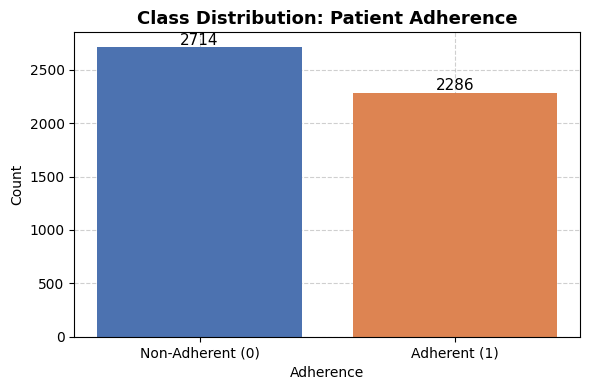

Class proportions:
Adherence
0    54.3
1    45.7
Name: proportion, dtype: float64


In [ ]:
# --------------------------------------------
# Class Distribution of Target Cell.
# --------------------------------------------

counts = df['Adherence'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Non-Adherent (0)', 'Adherent (1)'], counts.values, color=['#4c72b0', '#dd8452'])
ax.set_title('Class Distribution: Patient Adherence', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Adherence')
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=11)

ax.set_facecolor('white')
ax.set_axisbelow(True)

ax.grid(True, axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print('Class proportions:')
print(df['Adherence'].value_counts(normalize=True).round(3) * 100)

Before building any predictive models, we first examined the distribution of our target variable, Adherence, to understand how our data is structured. The bar chart in Figure 1 shows that out of 5,000 patients, 2,714 (54.3%) were non-adherent and 2,286 (45.7%) were adherent. The dataset has a mild class imbalance, which can cause models to favor the majority class and produce misleading accuracy scores. To account for this, we used F1 Macro score and ROC AUC as our primary evaluation metrics, as both measure performance equally across both classes regardless of their size.

In [ ]:
# -----------------------------------------------
# Encoding Categorical Variables
# Machine learning models require numerical inputs.
# LabelEncoder converts text categories to numbers.
# We create df_enc and keep df unchanged for EDA charts.
# -----------------------------------------------

# from sklearn.preprocessing import LabelEncoder

# cat_cols = ['Gender', 'Medication_Type', 'Education_Level',
            # 'Social_Support_Level', 'Condition_Severity',
            # 'Healthcare_Access', 'Mental_Health_Status']

# le = LabelEncoder()
# df_enc = df.copy()  # keep original df untouched for EDA charts

# for col in cat_cols:
    # df_enc[col] = le.fit_transform(df_enc[col])

# print('Encoding complete.')
# df_enc.head()

In [ ]:
print(df['Gender'].unique())
print(df['Medication_Type'].unique())

['Male' 'Female' 'Other']
['TypeA' 'TypeC' 'TypeB']


In [ ]:
# -----------------------------------------------
# Encoding Categorical Variables
# Label Encoding for ordinal, OHE for nominal
# Using skpre.OneHotEncoder per Chapter 10 method
# -----------------------------------------------

from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()

# --- Ordinal columns: Label Encode (order exists) ---
ordinal_cols = ['Education_Level', 'Social_Support_Level',
                'Condition_Severity', 'Healthcare_Access',
                'Mental_Health_Status']

le = LabelEncoder()
for col in ordinal_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

# --- Nominal columns: One-Hot Encode (no order) ---
# Using skpre.OneHotEncoder with drop='first' to avoid
# multicollinearity, per Chapter 10 notebook
nominal_cols = ['Gender', 'Medication_Type']

enc_gender = pd.DataFrame(
    skpre.OneHotEncoder(handle_unknown='error', drop='first')
         .fit_transform(df_enc[['Gender']]).toarray(),
    index=df_enc.index,
    columns=['Gender_1', 'Gender_2']
)

enc_medtype = pd.DataFrame(
    skpre.OneHotEncoder(handle_unknown='error', drop='first')
         .fit_transform(df_enc[['Medication_Type']]).toarray(),
    index=df_enc.index,
    columns=['MedType_1', 'MedType_2']
)

# Drop original nominal columns and join OHE columns
df_enc = df_enc.drop(columns=nominal_cols)
df_enc = df_enc.join(enc_gender).join(enc_medtype)

print('Encoding complete.')
df_enc.head()

Encoding complete.


,Age,Dosage_mg,Previous_Adherence,Education_Level,Income,Social_Support_Level,Condition_Severity,Comorbidities_Count,Healthcare_Access,Mental_Health_Status,Insurance_Coverage,Adherence,Gender_1,Gender_2,MedType_1,MedType_2
0,57,136,1,1,634934,2,2,3,2,0,1,1,1.0,0.0,0.0,0.0
1,47,134,1,1,297954,0,1,3,1,0,1,0,1.0,0.0,0.0,0.0
2,59,89,1,1,789337,0,1,1,1,0,1,1,1.0,0.0,0.0,1.0
3,72,240,0,2,267352,1,0,2,2,1,1,0,1.0,0.0,1.0,0.0
4,46,241,1,2,718447,2,0,1,2,0,1,0,1.0,0.0,0.0,0.0


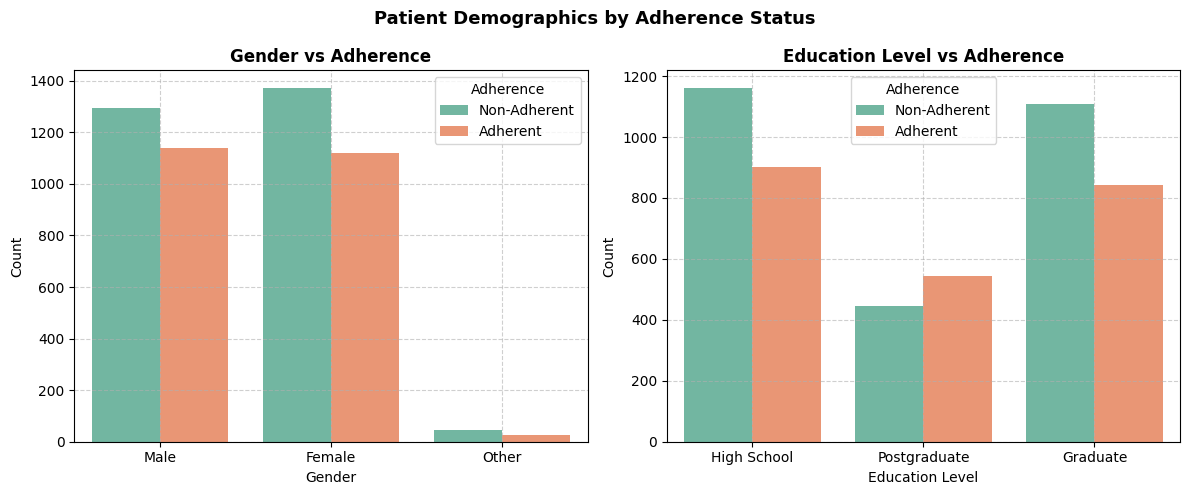

In [ ]:
# -----------------------------------------------
# 4.3 Patient Demographics by Adherence Status
# Examining how gender and education level vary
# between adherent and non-adherent patients.
# Uses original df to keep readable labels.
# -----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gender vs Adherence
sns.countplot(x='Gender', hue='Adherence', data=df,
              palette='Set2', ax=axes[0])
axes[0].set_title('Gender vs Adherence', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].legend(title='Adherence', labels=['Non-Adherent', 'Adherent'])
axes[0].grid(True, axis='both', linestyle='--', alpha=0.6)


# Education Level vs Adherence
sns.countplot(x='Education_Level', hue='Adherence', data=df,
              palette='Set2', ax=axes[1])
axes[1].set_title('Education Level vs Adherence', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Count')
axes[1].legend(title='Adherence', labels=['Non-Adherent', 'Adherent'])
axes[1].grid(True, axis='both', linestyle='--', alpha=0.6)


plt.suptitle('Patient Demographics by Adherence Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

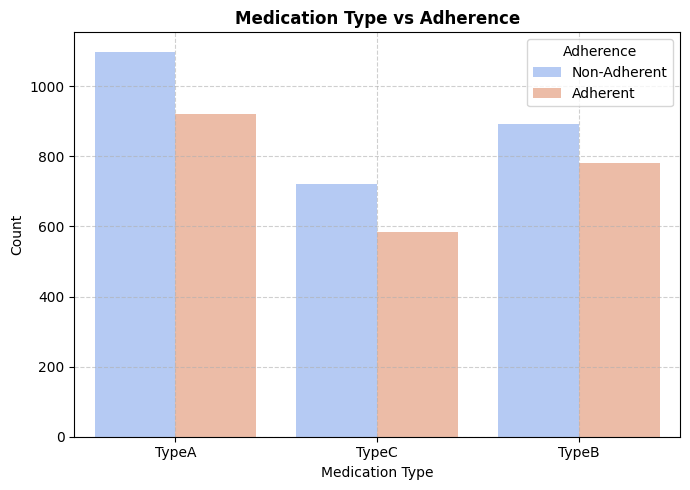

In [ ]:
# -----------------------------------------------
# 4.4 Medication Type Analysis
# Comparing adherence rates across TypeA, TypeB, TypeC
# to see if medication type influences non-adherence.
# Uses original df to keep readable labels.
# -----------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

sns.countplot(x='Medication_Type', hue='Adherence', data=df,
              palette='coolwarm', ax=ax)
ax.set_title('Medication Type vs Adherence', fontsize=12, fontweight='bold')
ax.set_xlabel('Medication Type')
ax.set_ylabel('Count')
ax.legend(title='Adherence', labels=['Non-Adherent', 'Adherent'])
ax.grid(True, axis='both', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

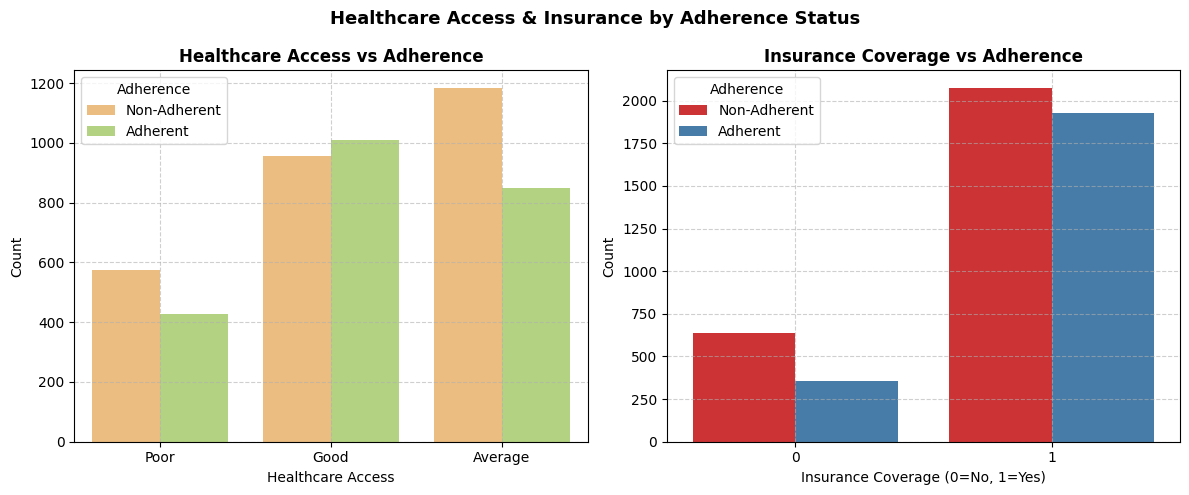

In [ ]:
# -----------------------------------------------
# 4.5 Healthcare Access & Insurance Distribution
# Examining how access to healthcare and insurance
# coverage relate to adherence outcomes.
# These are key structural barriers to adherence.
# Uses original df to keep readable labels.
# -----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Healthcare Access vs Adherence
sns.countplot(x='Healthcare_Access', hue='Adherence', data=df,
              palette='RdYlGn', ax=axes[0])
axes[0].set_title('Healthcare Access vs Adherence',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Healthcare Access')
axes[0].set_ylabel('Count')
axes[0].legend(title='Adherence', labels=['Non-Adherent', 'Adherent'])
axes[0].grid(True, axis='both', linestyle='--', alpha=0.6)

# Insurance Coverage vs Adherence
sns.countplot(x='Insurance_Coverage', hue='Adherence', data=df,
              palette='Set1', ax=axes[1])
axes[1].set_title('Insurance Coverage vs Adherence',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Insurance Coverage (0=No, 1=Yes)')
axes[1].set_ylabel('Count')
axes[1].legend(title='Adherence', labels=['Non-Adherent', 'Adherent'])
axes[1].grid(True, axis='both', linestyle='--', alpha=0.6)

plt.suptitle('Healthcare Access & Insurance by Adherence Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

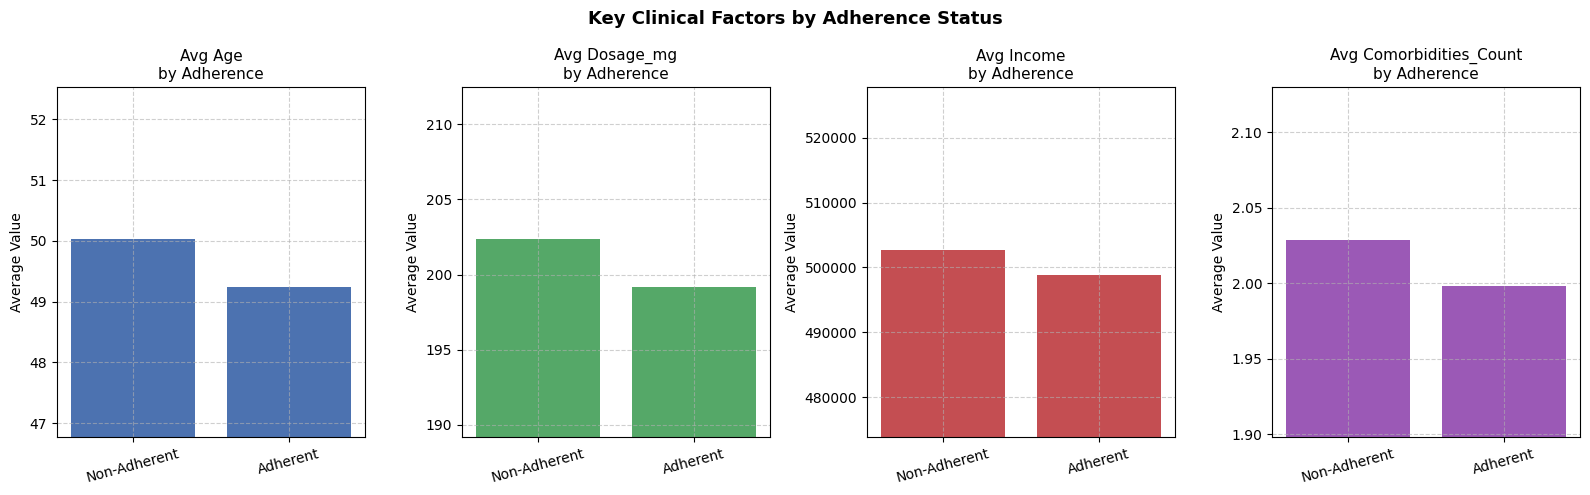

In [ ]:
# -----------------------------------------------
# 4.6 Key Clinical Factors by Adherence Status
# Comparing average values of numerical features
# between adherent and non-adherent patients.
# Uses df_enc since we need numerical groupby.
# -----------------------------------------------

grouped = df_enc.groupby('Adherence')[['Age', 'Dosage_mg',
                                        'Income',
                                        'Comorbidities_Count']].mean()

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
features = ['Age', 'Dosage_mg', 'Income', 'Comorbidities_Count']
colors = ['#4c72b0', '#55a868', '#c44e52', '#9b59b6']

for i, feat in enumerate(features):
    axes[i].bar(['Non-Adherent', 'Adherent'],
                [grouped[feat].loc[0], grouped[feat].loc[1]], color=colors[i])
    axes[i].set_title(f'Avg {feat}\nby Adherence', fontsize=11)
    axes[i].set_ylabel('Average Value')
    axes[i].set_ylim(grouped[feat].min() * 0.95,
                     grouped[feat].max() * 1.05)

    axes[i].tick_params(axis='x', labelrotation=15)
    axes[i].grid(True, axis='both', linestyle='--', alpha=0.6)



plt.suptitle('Key Clinical Factors by Adherence Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

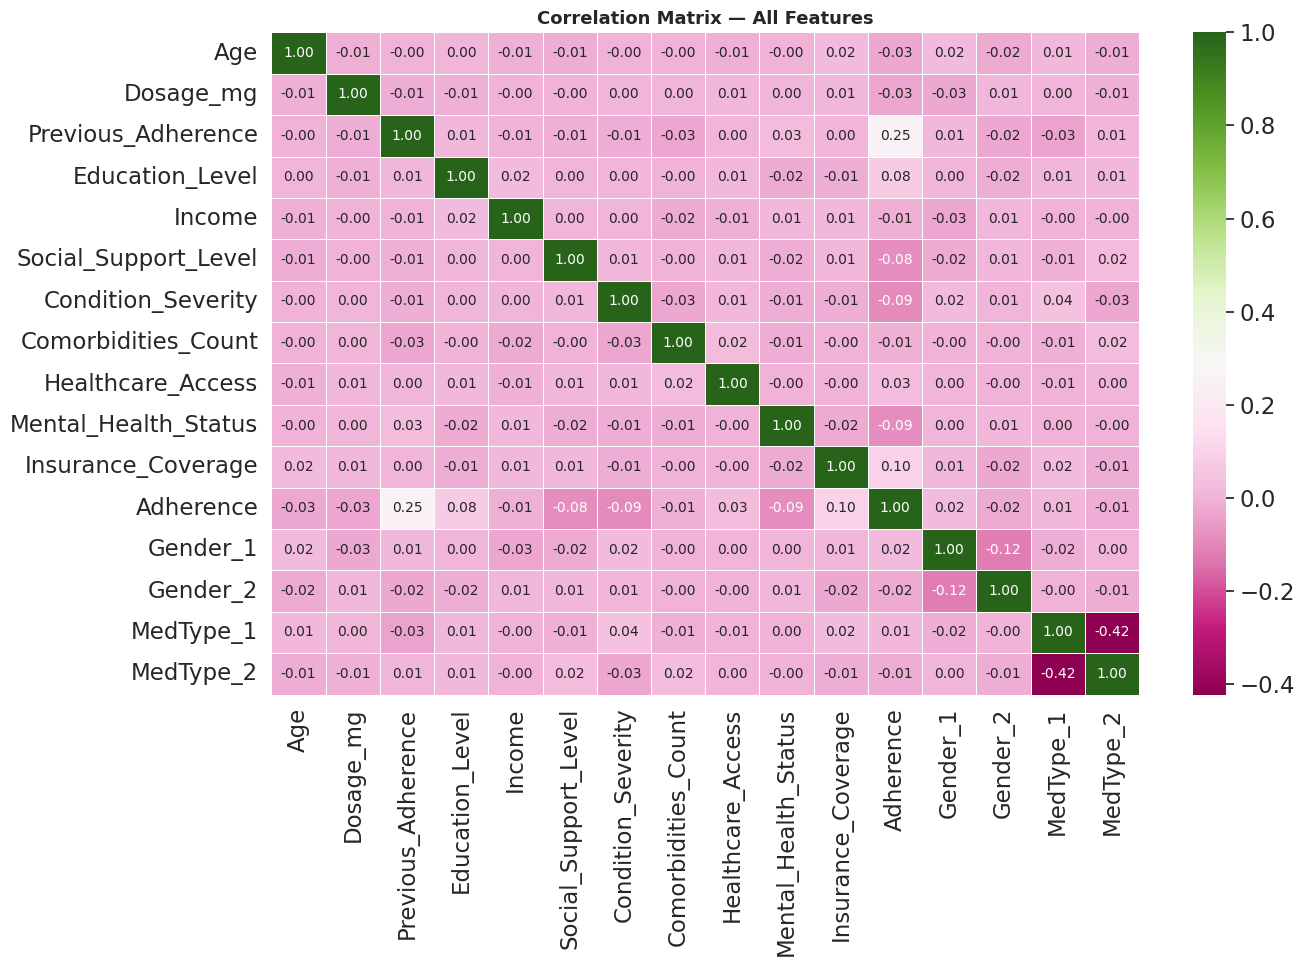

In [ ]:
# -----------------------------------------------
# 4.7 Correlation Analysis
# we want to compute the correlation matrix
# to understand relationships between all features
# and identify which variables are most related
# to our target variable Adherence
# -----------------------------------------------

# computing the correlation matrix
correlation = df_enc.corr()

# creating a heatmap plot as used in class
sns.set(font_scale=1.5)
plt.figure(figsize=(14, 10))
ax = sns.heatmap(correlation,
                 annot=True,
                 annot_kws={"size": 10},
                 fmt='.2f',
                 cmap='PiYG',
                 linewidths=.5)
plt.title('Correlation Matrix — All Features',
          fontsize=13,
          fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------
# Train/Test Split
# splitting the data into training and test sets
# 67% training, 33% test
# random_state=21 ensures reproducibility
# X contains all features, y is the target variable
# -----------------------------------------------

X = df_enc.drop(columns=['Adherence'])
y = df_enc['Adherence']

# using skms which is how professor imports model_selection
tts = skms.train_test_split(X, y,
                             test_size=.33,
                             random_state=21)
(X_train, X_test,
 y_train, y_test) = tts

print('Training set:', X_train.shape)
print('Test set:    ', X_test.shape)
print('\nTraining target distribution:')
print(y_train.value_counts())


# -----------------------------------------------
# Feature Engineering (post-split)
# Avg_Income_by_Education computed from training data only, then mapped to test set.
# -----------------------------------------------
avg_income_edu = X_train.groupby('Education_Level')['Income'].mean()
X_train['Avg_Income_by_Education'] = X_train['Education_Level'].map(avg_income_edu)
X_test['Avg_Income_by_Education']  = X_test['Education_Level'].map(avg_income_edu)

# -----------------------------------------------
# Standardization
# fit_transform on train only, transform on test.
# -----------------------------------------------
numeric_cols = ['Age', 'Dosage_mg', 'Income',
                'Comorbidities_Count', 'Avg_Income_by_Education']

scaler = skpre.StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print('Feature engineering and standardization complete (post-split).')
print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)

Training set: (3350, 15)
Test set:     (1650, 15)

Training target distribution:
Adherence
0    1808
1    1542
Name: count, dtype: int64
Feature engineering and standardization complete (post-split).
X_train shape: (3350, 16)
X_test shape:  (1650, 16)


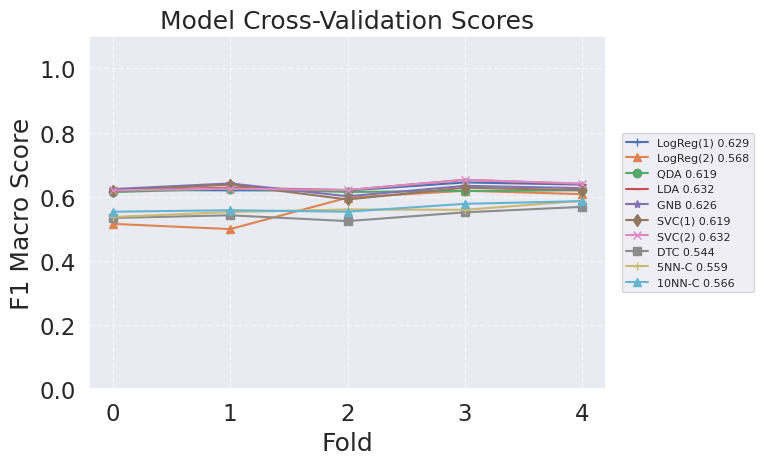

In [ ]:
# -----------------------------------------------
# 6.2 Classifier Parade & Model Selection
# Testing 10 different classification models using
# 5-fold cross-validation with F1 Macro Score.
# F1 Macro is used instead of accuracy because it
# equally weights both classes regardless of size.
# We select the two best Chapter 8 models for
# detailed analysis as required by BUA 611 rubric.
# -----------------------------------------------

classifier_parade = {
    'LogReg(1)' : linear_model.LogisticRegression(max_iter=1000),
    'LogReg(2)' : linear_model.SGDClassifier(loss='log_loss',
                                              max_iter=1000),
    'QDA'       : discriminant_analysis.QuadraticDiscriminantAnalysis(),
    'LDA'       : discriminant_analysis.LinearDiscriminantAnalysis(),
    'GNB'       : naive_bayes.GaussianNB(),
    'SVC(1)'    : svm.SVC(kernel='linear'),
    'SVC(2)'    : svm.LinearSVC(),
    'DTC'       : tree.DecisionTreeClassifier(),
    '5NN-C'     : neighbors.KNeighborsClassifier(),
    '10NN-C'    : neighbors.KNeighborsClassifier(n_neighbors=10)
}

baseline = dummy.DummyClassifier(strategy='uniform')

# plotting cross validation scores for each model
fig, ax = plt.subplots(figsize=(8, 5))

markers = it.cycle(['+', '^', 'o', '_', '*', 'd', 'x', 's'])

for name, model in classifier_parade.items():
    cv_scores = skms.cross_val_score(model, X_train, y_train,
                                     cv=5,
                                     scoring='f1_macro',
                                     n_jobs=-1)
    my_lbl = '{} {:.3f}'.format(name, cv_scores.mean())
    ax.plot(cv_scores, label=my_lbl, marker=next(markers))

ax.set_ylim(0.0, 1.1)
ax.set_xlabel('Fold')
ax.set_ylabel('F1 Macro Score')
ax.set_title('Model Cross-Validation Scores')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    ncol=1,
    frameon=True
)

plt.tight_layout()
plt.show()

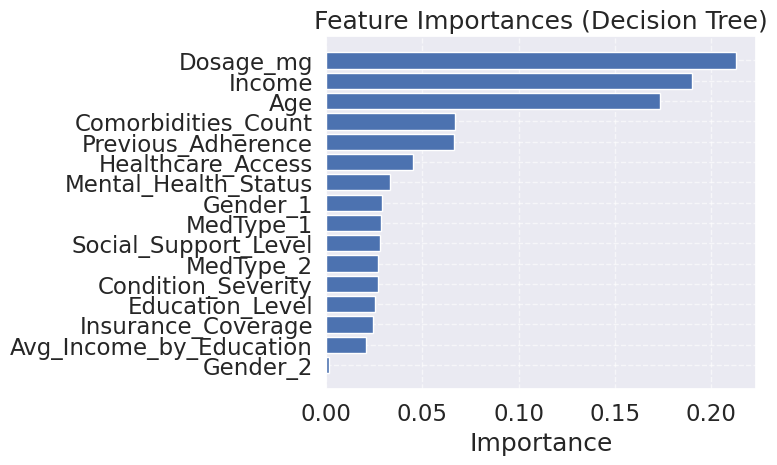

In [ ]:
# -----------------------------------------------
# 6.3 Decision Tree Classifier
# First examining feature importances using
# an unrestricted tree to understand which
# variables contribute most to predicting adherence
# -----------------------------------------------

dtc = tree.DecisionTreeClassifier(random_state=0)
skms.cross_val_score(dtc,
                     X_train, y_train,
                     cv=3,
                     scoring='accuracy')

# fitting the tree to get feature importances
dtc = dtc.fit(X_train, y_train)

importances = dtc.feature_importances_
impor_df = pd.DataFrame({
    'Feature name': X_train.columns,
    'Importance': importances
})
final_df = impor_df.sort_values(by='Importance', ascending=False)

# plotting feature importances as horizontal bar chart
plt.figure(figsize=(8, 5))
plt.barh(final_df['Feature name'][::-1], final_df['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Feature Importances (Decision Tree)')
ax.set_facecolor('white')
ax.set_axisbelow(True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


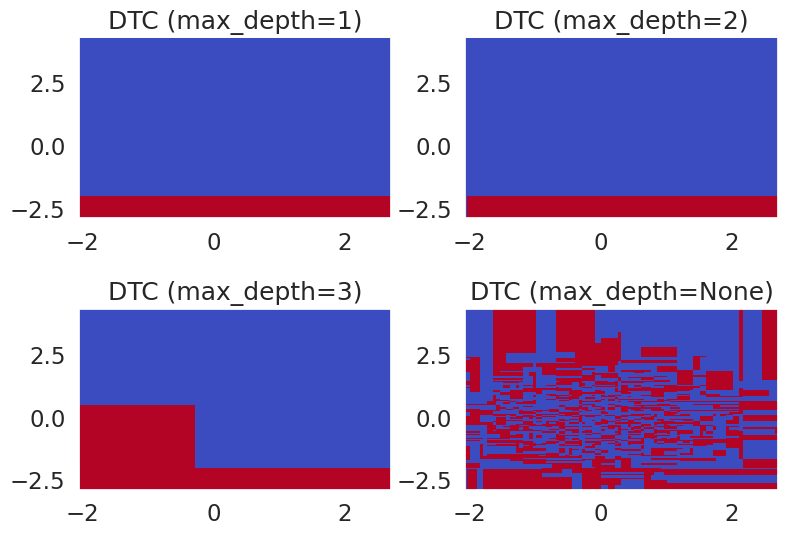

In [ ]:
# -----------------------------------------------
# Decision boundaries at different tree depths
# Used to select optimal max_depth to avoid
# overfitting. max_depth=None creates irregular
# boundaries showing memorization of training data.
# max_depth=3 provides the best balance.
# -----------------------------------------------

def plot_boundary(ax, data, tgt, model, dims, grid_step=.05):
    twoD = data.iloc[:, list(dims)] if hasattr(data, 'iloc') else data[:, list(dims)]
    min_x1, min_x2 = np.min(twoD, axis=0) + 2 * grid_step
    max_x1, max_x2 = np.max(twoD, axis=0) - grid_step
    xs, ys = np.mgrid[min_x1:max_x1:grid_step,
                      min_x2:max_x2:grid_step]
    grid_points = np.c_[xs.ravel(), ys.ravel()]
    preds = model.fit(twoD, tgt).predict(grid_points).reshape(xs.shape)
    ax.pcolormesh(xs, ys, preds, cmap=plt.cm.coolwarm)
    ax.set_xlim(min_x1, max_x1)
    ax.set_ylim(min_x2, max_x2)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
depths = [1, 2, 3, None]

X_2D = X_train.iloc[:, [0, 1]]
y_bin = y_train

for depth, ax in zip(depths, axes.flat):
    dtc_model = tree.DecisionTreeClassifier(max_depth=depth)
    plot_boundary(ax, X_2D, y_bin, dtc_model, [0, 1])
    ax.set_title(f'DTC (max_depth={depth})')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

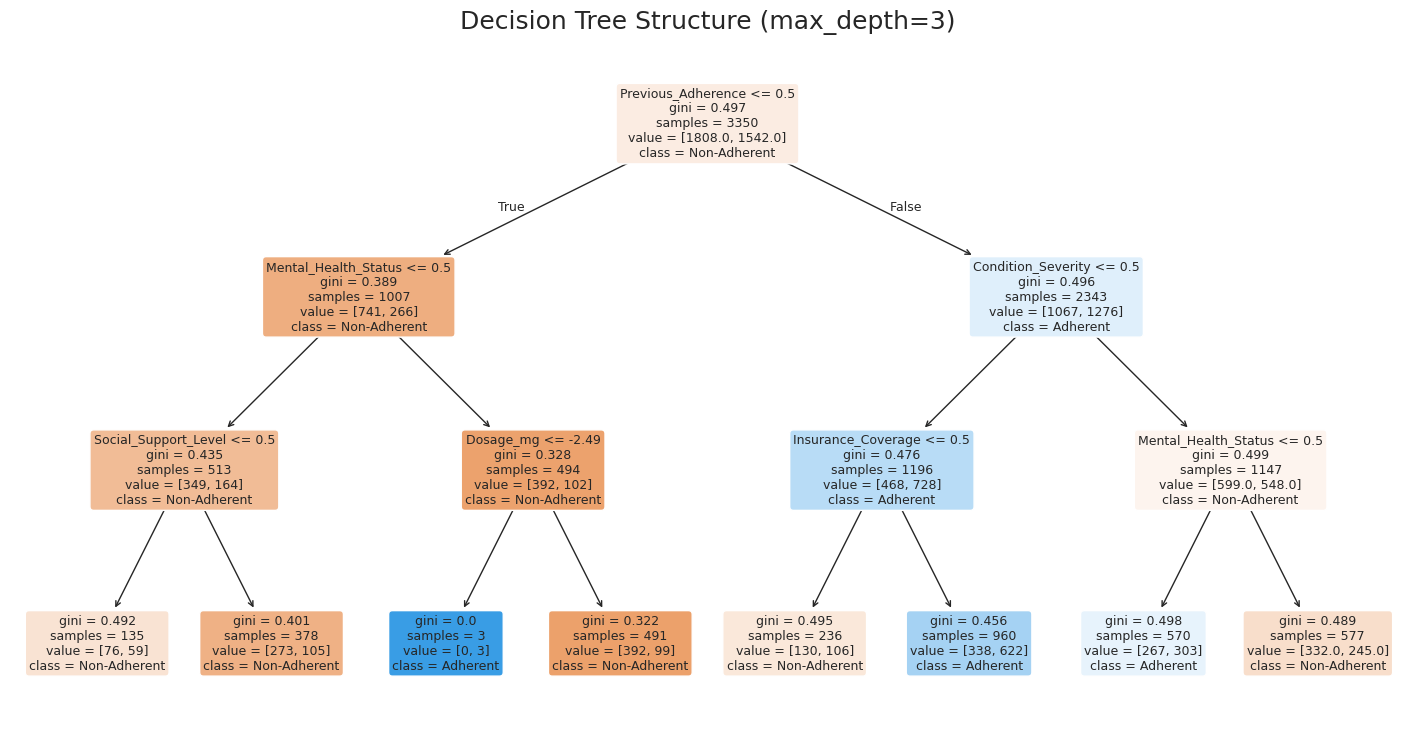

In [ ]:
# -----------------------------------------------
# Decision Tree Structure Visualization
# max_depth=3 selected to avoid overfitting
# 3-fold cross-validation used for evaluation
# First split based on Previous_Adherence
# -----------------------------------------------

from sklearn.tree import DecisionTreeClassifier, plot_tree

dtc = DecisionTreeClassifier(max_depth=3, random_state=0)
dtc.fit(X_train, y_train)

# visualizing the tree structure
plt.figure(figsize=(18, 9))
plot_tree(dtc,
          feature_names=X_train.columns,
          class_names=['Non-Adherent', 'Adherent'],
          filled=True,
          rounded=True,
          fontsize=9)
plt.title('Decision Tree Structure (max_depth=3)')
plt.show()

=== Decision Tree - Test Set Performance ===
Accuracy: 0.618

Classification Report:
              precision    recall  f1-score   support

Non-Adherent       0.66      0.63      0.64       906
    Adherent       0.57      0.60      0.59       744

    accuracy                           0.62      1650
   macro avg       0.62      0.62      0.62      1650
weighted avg       0.62      0.62      0.62      1650



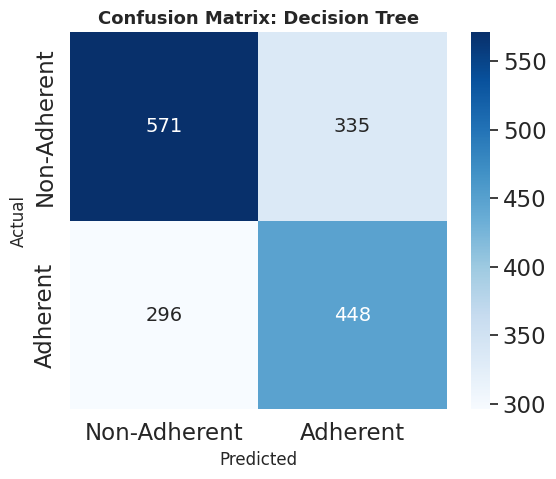

DTC 5-Fold CV F1 Macro: [0.599 0.633 0.592 0.598 0.633]
Mean: 0.611


In [ ]:
# -----------------------------------------------
# DTC Evaluation on test set
# Accuracy, confusion matrix, classification report
# -----------------------------------------------

dtc_preds = dtc.predict(X_test)
dtc_proba = dtc.predict_proba(X_test)[:, 1]

print('=== Decision Tree - Test Set Performance ===')
print('Accuracy:', round(metrics.accuracy_score(y_test, dtc_preds), 3))
print('\nClassification Report:')
print(metrics.classification_report(y_test, dtc_preds,
      target_names=['Non-Adherent', 'Adherent']))

# confusion matrix
cm_dtc = metrics.confusion_matrix(y_test, dtc_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Blues',
            square=True,
            xticklabels=['Non-Adherent', 'Adherent'],
            yticklabels=['Non-Adherent', 'Adherent'],
            annot_kws={'size': 14}, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix: Decision Tree', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

# cross validation
cv_dtc = skms.cross_val_score(dtc, X_train, y_train,
                               cv=5, scoring='f1_macro')
print('DTC 5-Fold CV F1 Macro:', np.round(cv_dtc, 3))
print('Mean:', round(cv_dtc.mean(), 3))

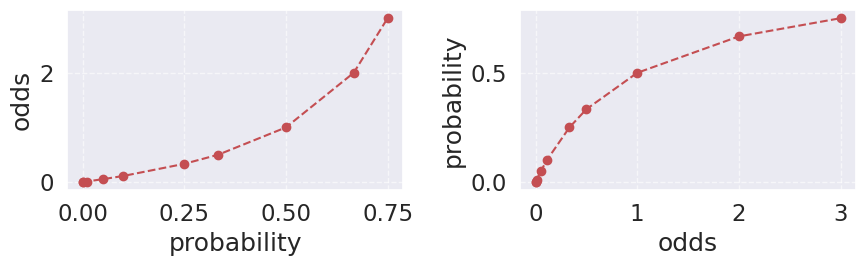

In [ ]:
# -----------------------------------------------
# 6.4 Logistic Regression
# Visualizing the relationship between probability
# and odds — the mathematical foundation of
# logistic regression as covered in the textbook
# -----------------------------------------------

tail_probs = [0.0, 0.001, 0.01, 0.05, 0.10, 0.25, 1.0/3.0]
lwr_probs = np.array(tail_probs)
upr_probs = 1 - lwr_probs[::-1]
cent_prob = np.array([0.5])
demo_probs = np.concatenate([lwr_probs, cent_prob, upr_probs])

with np.errstate(divide='ignore'):
    odds = demo_probs / (1 - demo_probs)
    log_odds = np.log(odds)

def helper(ax, x, y, x_name, y_name):
    ax.plot(x, y, 'r--o')
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.grid(True, linestyle='--', alpha=0.6)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9, 3))
helper(ax0, demo_probs[:-5], odds[:-5], 'probability', 'odds')
helper(ax1, odds[:-5], demo_probs[:-5], 'odds', 'probability')

plt.tight_layout()
plt.show()

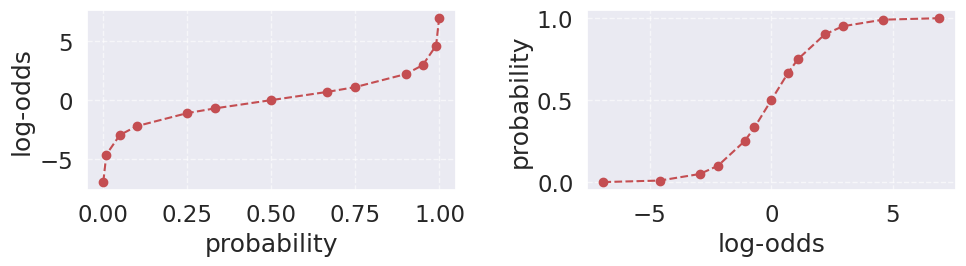

In [ ]:
# -----------------------------------------------
# Probability vs Log-Odds visualization
# Shows the S-shaped sigmoid curve that logistic
# regression uses to convert log-odds to
# probabilities between 0 and 1
# -----------------------------------------------

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3))
helper(ax0, demo_probs, log_odds, 'probability', 'log-odds')
helper(ax1, log_odds, demo_probs, 'log-odds', 'probability')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


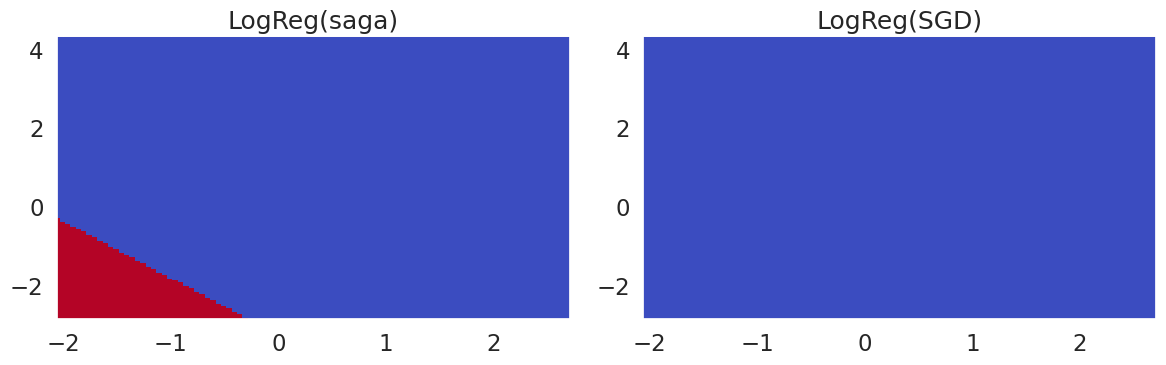

In [ ]:
# -----------------------------------------------
# Comparing SAGA and SGD solvers through
# decision boundary visualization
# SAGA produces more balanced boundaries
# SGD shows signs of class bias
# -----------------------------------------------

LogReg = linear_model.LogisticRegression
SGD    = linear_model.SGDClassifier

logreg_classifiers = {
    'LogReg(saga)': LogReg(solver='saga',
                           max_iter=1000),
    'LogReg(SGD)' : SGD(loss='log_loss',
                        max_iter=1000)
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flat
for (name, mod), ax in zip(logreg_classifiers.items(), axes):
    plot_boundary(ax, X_train, y_train, mod, [0, 1])
    ax.set_title(name)
plt.tight_layout()
plt.show()

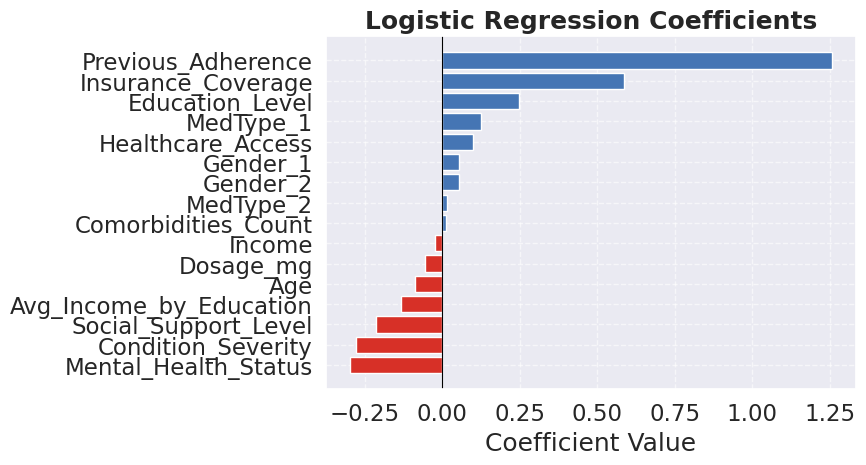

In [ ]:
# -----------------------------------------------
# Fitting final Logistic Regression model
# Using SAGA solver selected from comparison above
# Plotting feature coefficients to understand
# which features drive adherence predictions
# Blue = increases adherence probability
# Red = decreases adherence probability
# -----------------------------------------------

logreg = linear_model.LogisticRegression(solver='saga',
                                          max_iter=1000,
                                          random_state=42)
logreg.fit(X_train, y_train)

# coefficient plot
coefs = pd.Series(logreg.coef_[0], index=X_train.columns)
coefs_sorted = coefs.sort_values()
bar_colors = ['#d73027' if c < 0 else '#4575b4' for c in coefs_sorted]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coefs_sorted.index, coefs_sorted.values, color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression Coefficients',
             fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

accuracy: 0.6272727272727273
confusion matrix:
[[581 325]
 [290 454]]


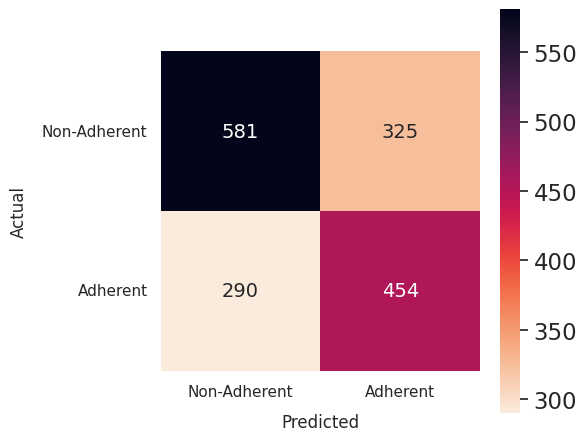

              precision    recall  f1-score   support

           0       0.67      0.64      0.65       906
           1       0.58      0.61      0.60       744

    accuracy                           0.63      1650
   macro avg       0.62      0.63      0.63      1650
weighted avg       0.63      0.63      0.63      1650

row counts equal support: [906 744]
LR CV F1 Macro: 0.629


In [ ]:
# -----------------------------------------------
# Logistic Regression evaluation on test set
# Accuracy, confusion matrix, classification report
# -----------------------------------------------


lr_preds = logreg.predict(X_test)
lr_proba = logreg.predict_proba(X_test)[:, 1]

# accuracy
print("accuracy:", metrics.accuracy_score(y_test, lr_preds))

# confusion matrix
cm = metrics.confusion_matrix(y_test, lr_preds)
print("confusion matrix:", cm, sep="\n")

# heatmap of confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r',
            square=True,
            xticklabels=['Non-Adherent', 'Adherent'],
            yticklabels=['Non-Adherent', 'Adherent'],
            cbar=True,
            annot_kws={"size": 14})
ax.set_xlabel('Predicted', fontsize=12, labelpad=10)
ax.set_ylabel('Actual', fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(pad=3.0)
plt.show()

# classification report
print(metrics.classification_report(y_test, lr_preds))

# verify row counts equal support
cm = metrics.confusion_matrix(y_test, lr_preds)
print("row counts equal support:", cm.sum(axis=1))

# cross validation
cv_scores = skms.cross_val_score(logreg, X_train, y_train,
                                  cv=5,
                                  scoring='f1_macro',
                                  n_jobs=-1)
print("LR CV F1 Macro: {:.3f}".format(cv_scores.mean()))

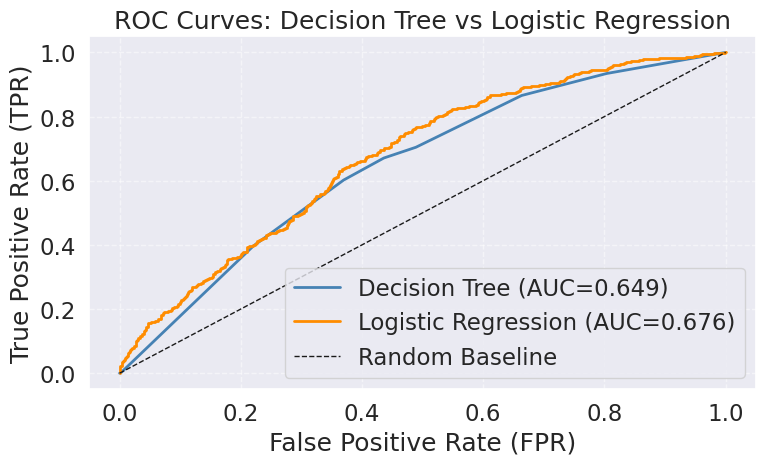

In [ ]:
# -----------------------------------------------
# Model Performance Comparison
# ROC Curves for both models on one chart
# ROC AUC measures ability to distinguish between
# adherent and non-adherent patients across all
# decision thresholds
# -----------------------------------------------

# getting predicted probabilities for both models
dtc_proba = dtc.predict_proba(X_test)[:, 1]
lr_proba = logreg.predict_proba(X_test)[:, 1]

# computing ROC curves
fpr_dtc, tpr_dtc, _ = metrics.roc_curve(y_test, dtc_proba)
fpr_lr, tpr_lr, _ = metrics.roc_curve(y_test, lr_proba)

auc_dtc = metrics.roc_auc_score(y_test, dtc_proba)
auc_lr = metrics.roc_auc_score(y_test, lr_proba)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fpr_dtc, tpr_dtc,
        label='Decision Tree (AUC={:.3f})'.format(auc_dtc),
        color='steelblue', lw=2)
ax.plot(fpr_lr, tpr_lr,
        label='Logistic Regression (AUC={:.3f})'.format(auc_lr),
        color='darkorange', lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curves: Decision Tree vs Logistic Regression')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------
# Model comparison bar chart
# Comparing Accuracy, Recall, F1 Score, ROC AUC
# across both models using 5-fold cross validation
# -----------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {
    'Decision Tree': tree.DecisionTreeClassifier(max_depth=3,
                                                  random_state=0),
    'Logistic Regression': linear_model.LogisticRegression(
                                        solver='saga',
                                        max_iter=1000,
                                        random_state=42)
}

scoring = {
    'Accuracy'  : 'accuracy',
    'Recall'    : 'recall_macro',
    'F1 Score'  : 'f1_macro',
    'ROC AUC'   : 'roc_auc'
}

results = []
for model_name, model in models.items():
    row = {'Model': model_name}
    for score_name, scorer in scoring.items():
        scores = skms.cross_val_score(model, X_train, y_train,
                                       cv=5, scoring=scorer)
        row[score_name] = round(scores.mean(), 3)
    results.append(row)

results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)
print(results_df)

                     Accuracy  Recall  F1 Score  ROC AUC
Model                                                   
Decision Tree           0.616   0.613     0.611    0.659
Logistic Regression     0.632   0.630     0.629    0.686


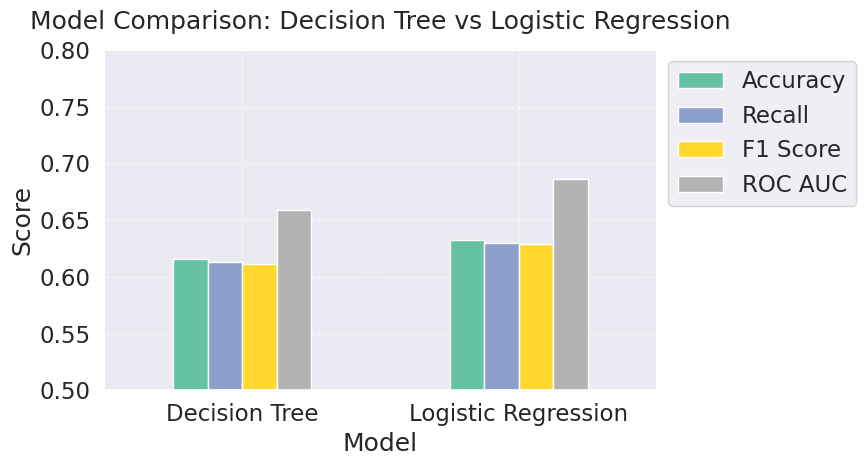

In [ ]:
# -----------------------------------------------
# Plotting the model comparison bar chart
# -----------------------------------------------

ax = results_df.plot(kind='bar', figsize=(9, 5),
                     colormap='Set2')
plt.title('Model Comparison: Decision Tree vs Logistic Regression',
          pad=15)
plt.ylabel('Score')
plt.ylim(0.50, 0.80)
plt.xticks(rotation=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()